In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

#### **Dataset Heart Disease Prediction**

https://www.kaggle.com/datasets/algozee/heart-decices

Vamos a querer predecir la columna `Heart Disease`

In [4]:
df = pd.read_csv("heart.csv").drop(columns=["id"])

df["Heart Disease"] = df["Heart Disease"].map({
    "Presence": 1,
    "Absence": 0
})

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [26]:
df["Heart Disease"].value_counts()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64

¿Qué significaría un error grave en este contexto?

#### **Train/Test Splits**

In [ ]:
X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

X_train, X_test, y_train, y_test = train_test_split( 
    X, y,
    test_size=0.2,
    random_state=42
)

---
#### **Modelo (Logistic Regression)**

Vamos a fitear una regresión logística y extraer las probabilidades de la clase positiva para cada muestra.

In [6]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

y_prob

array([0.17149202, 0.39882505, 0.99549734, ..., 0.61286824, 0.35318104,
       0.19890525])

---
#### **Matriz de confusión + Visualización**

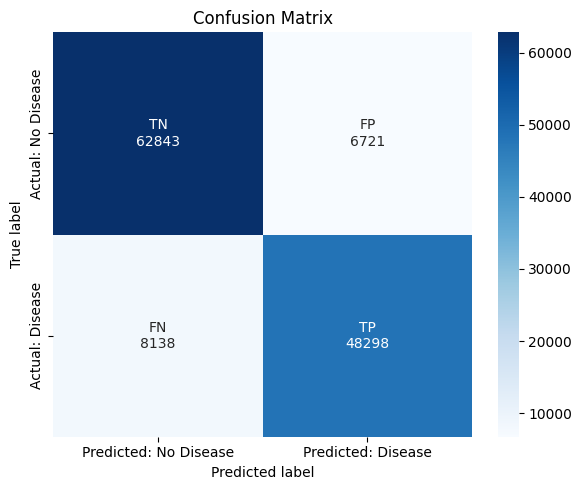

In [27]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

labels = [
    f"TN\n{TN}",
    f"FP\n{FP}",
    f"FN\n{FN}",
    f"TP\n{TP}"
]

labels = np.array(labels).reshape(2,2)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Predicted: No Disease", "Predicted: Disease"],
    yticklabels=["Actual: No Disease", "Actual: Disease"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

Si tuvieras que minimizar un solo tipo de error, ¿cuál elegirías?

---
#### **Métricas - Completar**

Usar TN, FP, FN, TP

¿Podría un modelo tener alta accuracy pero ser inútil?

In [ ]:
accuracy = ...
precision = ...
recall = ...
f1 = ...

Comparar a continuación con los resultados obtenidos de sklearn

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8820714285714286
Precision: 0.8778421999672841
Recall: 0.8558012616060671
F1: 0.8666816203849087


---
#### **Completar la siguiente tabla para los valores de threshold indicados utilizando el código a continuación**

| Threshold | Precision | Recall | F1 |
| --------- | --------- | ------ | -- |
| 0.9       |           |        |    |
| 0.7       |           |        |    |
| 0.5       |           |        |    |
| 0.3       |           |        |    |
| 0.1       |           |        |    |
| 0.0       |           |        |    |

¿Qué threshold elegirías de la tabla para el modelo final?

¿Qué pasa con precision y recall cuando bajamos el threshold?

In [21]:
threshold = 0.3

y_pred_threshold = (y_prob > threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall:", recall_score(y_test, y_pred_threshold))
print("F1:", f1_score(y_test, y_pred_threshold))

Accuracy: 0.8701587301587301
Precision: 0.8147461673787384
Recall: 0.9190941951945567
F1: 0.8637801831806827


---
#### **Curva PR**

¿Por qué esta curva es útil con clases desbalanceadas?

¿En qué punto de la gráfica estamos cuando threshold = 0?¿A qué se debe ese valor de Y (Precision)?

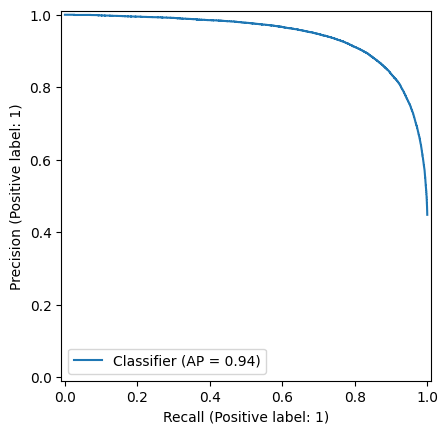

In [25]:
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.show()

---
#### **Curva ROC**

¿Qué valor de AUC tendría un modelo completamente aleatorio? ¿Y un modelo perfecto?

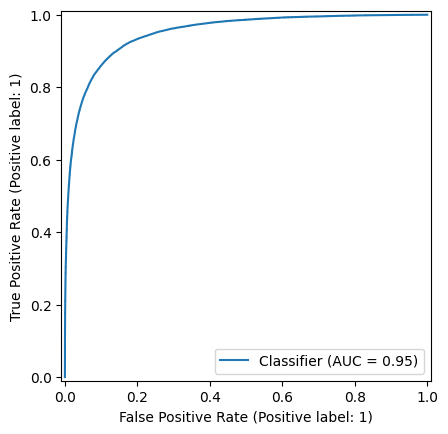

In [23]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()